# MDR-TS v16.1
**Temporal-Station Baseline Model for Soil Moisture Prediction**

**Author:** Jakob Balkovec  
**Affiliation:** Seattle University, Computer Science  
**Project:** MDR
**Notebook Type:** Training & Evaluation  
**Last Updated:** Tue Jan 6th 2026

---

## Model Summary
- **Model Name:** MDR-TS  
- **Version:** v16.1
- **Task:** Regression (Soil Moisture at 5 cm depth)  
- **Target Variable:** `soil_moisture_5cm`  
- **Temporal Resolution:** Daily  

---

## Reproducibility
- **Random Seed:** 42
- **Split Metadata:** `data/splits/base/split_meta.json`
- **Environment:** Google Colab / VS Code Remote Kernel

---

Adapted for a Macbook M2 Pro environment.

**What's new?**

Weighing the years. Further analysis provided at the end. `@see` [Analysis](#analysis)

For other info see `MDR-TS-v1.0`

## 0. Imports

In [82]:
import os
import json
import math
import random
from pathlib import Path

# Data
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML / Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import mahalanobis
from numpy.linalg import inv
from sklearn.decomposition import PCA

# Gradient Boosting (baseline model)
from xgboost import XGBRegressor

# PyTorch
import torch

# Warnings
import warnings
warnings.filterwarnings("ignore")

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("imports loaded")
print(f"using: {device}")

imports loaded
using: cpu


## 1. Environment Setup

In [43]:
# Reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

print(f"Random seed set to {SEED}")

# Environment / Runtime Info
def print_env_info():
    print("Environment information:")
    print(f"  Python version: {os.sys.version.split()[0]}")
    print(f"  NumPy version:  {np.__version__}")
    print(f"  Pandas version: {pd.__version__}")

    try:
        import xgboost
        print(f"  XGBoost version: {xgboost.__version__}")
    except ImportError:
        print("  XGBoost not installed")

    # Colab-specific checks
    IN_COLAB = "COLAB_GPU" in os.environ
    print(f"  Running in Colab: {IN_COLAB}")

    if IN_COLAB:
        gpu = os.environ.get("COLAB_GPU", None)
        print(f"  GPU available: {gpu}")
    else:
        print("  GPU available: False")

print_env_info()

# Plotting defaults
plt.style.use("default")
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("environment setup complete")

Random seed set to 42
Environment information:
  Python version: 3.10.18
  NumPy version:  1.26.4
  Pandas version: 2.0.3
  XGBoost version: 3.2.0
  Running in Colab: False
  GPU available: False
environment setup complete


## 2. Data Access

In [ ]:
# Project paths
VERSION = "v16"
SUBVERSION = "v16.1"
RUN_NAME = "mdr_ts_v16_1"

PROJECT_ROOT = "/Users/jbalkovec/Desktop/MDR"
DATA_ROOT = f"{PROJECT_ROOT}/Temporal/Pipeline/data"
SPLIT_ROOT = f"{DATA_ROOT}/splits"
OUTPUT_ROOT = f"{PROJECT_ROOT}/Models/Temporal/{VERSION}/{SUBVERSION}"

# Create output directory if missing
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Project paths:")
print(f"  PROJECT_ROOT: {PROJECT_ROOT}")
print(f"  DATA_ROOT:    {DATA_ROOT}")
print(f"  SPLIT_ROOT:   {SPLIT_ROOT}")
print(f"  OUTPUT_ROOT:  {OUTPUT_ROOT}")

print("\nKey file checks:")
print("  data exists:",
      os.path.exists(DATA_ROOT))
print("  splits exists:",
      os.path.exists(SPLIT_ROOT))
print("  output exists:",
      os.path.exists(OUTPUT_ROOT))

Project paths:
  PROJECT_ROOT: /Users/jbalkovec/Desktop/MDR
  DATA_ROOT:    /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data
  SPLIT_ROOT:   /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits
  OUTPUT_ROOT:  /Users/jbalkovec/Desktop/MDR/Models/Temporal/v16/v16.2

Key file checks:
  data exists: True
  splits exists: True
  output exists: True


## 3. Data Loading

In [45]:
TRAIN_PATH = str(Path(SPLIT_ROOT) / "derived_6.0/train.csv")
VAL_PATH   = str(Path(SPLIT_ROOT) / "derived_6.0/val.csv")
TEST_PATH  = str(Path(SPLIT_ROOT) / "derived_6.0/test.csv")

for p in [TRAIN_PATH, VAL_PATH, TEST_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing split file: {p}")

print("Split files:")
print(" ", TRAIN_PATH)
print(" ", VAL_PATH)
print(" ", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
val_df   = pd.read_csv(VAL_PATH)
test_df  = pd.read_csv(TEST_PATH)

Split files:
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/train.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/val.csv
  /Users/jbalkovec/Desktop/MDR/Temporal/Pipeline/data/splits/derived_6.0/test.csv


In [46]:
print("Common columns across splits:",
      len(set(train_df.columns) & set(val_df.columns) & set(test_df.columns)))

print("\ncolumns:")
print(list(train_df.columns)[:30])

Common columns across splits: 489

columns:
['station_id', 'date', 'longitude', 'latitude', 'precip_mm', 's1_vv', 's1_vh', 's2_b4', 's2_b8', 's2_b11', 's2_b12', 'LST_modis', 'elev', 'slope', 'aspect', 'DOY', 'SMAP_sm_am_interp', 'SMAP_sm_pm_interp', 'soil_moisture_5cm', 'J_aspect_deg', 'J_bio_bio01', 'J_bio_bio02', 'J_bio_bio03', 'J_bio_bio04', 'J_bio_bio05', 'J_bio_bio06', 'J_bio_bio07', 'J_bio_bio08', 'J_bio_bio09', 'J_bio_bio10']


## 4. Data Sanity Checks

In [47]:
# Column definitions (baseline)
TARGET_COL = "soil_moisture_5cm"

KEEP_META_COLS = ["station_id", "date", "longitude", "latitude"]

FEATURE_COLS = [
        "SMAP_sm_pm_interp_ema02",
        "V_rollmin_LST_modis_kobs30",
        "D_sin_DOY",
        "G_rain_sum_3d",
        "V_ema_G_API_kobs7",
        "V_rollmin_G_API_kobs30",
        "G_rain_sum_7d",
        "C_lag_LST_modis_kobs30",
        "C_lag_G_API_kobs1",
        "V_ema_G_API_kobs14",
        "V_rollmean_G_API_kobs14",
        "G_API",
        "A_pct_G_API",
        "V_rollcv_G_API_kobs30",
        "G_DSLR",
        "SMAP_ampm_diff_interp",
        "V_rollmax_G_API_kobs30",
        "V_rollmin_G_API_kobs7",
        "V_ema_G_API_kobs30",
        "V_rollmean_s2_b11_kobs7",
        "V_ema_LST_modis_kobs7",
        "C_smm_G_API_alpha0.85_n5",
        "C_lag_G_API_kobs5",
        "V_rollmean_G_API_kobs7",
        "C_lag_s2_b11_kobs30",
        "D_z_LST_modis",
        "A_d_G_API_kobs1",
        "V_rollcv_LST_modis_kobs30",
        "V_rollcv_G_API_kobs7",
        "V_rollstd_LST_modis_kobs30",
        "A_d_E_SAR_diff_kobs14",
        "C_lag_G_API_kobs6",
        "V_rollrng_F_NDMI_kobs7",
        "V_rollcv_G_API_kobs14",
        "C_lag_LST_modis_kobs6",
        "A_d_E_SAR_diff_kobs30",
        "A_d_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollrange7",
        "V_rollstd_LST_modis_kobs14",
        "D_fft_ent_E_SAR_ratio_kobs30",
        "A_d_E_SAR_diff_kobs5",
        "SMAP_sm_pm_interp_rollrange7",
        "V_rollstd_F_NDMI_kobs7",
        "V_rollstd_E_SAR_ratio_kobs7",
        "V_rollrng_E_SAR_diff_kobs7",
        "V_rollstd_s2_b12_kobs7",
        "A_grad_E_SAR_diff_kobs14",
        "D_fft_dom_LST_modis_kobs30",
        "V_rollcv_s2_b12_kobs7",
        "A_d_E_SAR_ratio_kobs5",
        "D_fft_ent_LST_modis_kobs30",
        "V_rollstd_F_NDVI_kobs7",
        "A_grad_s2_b12_kobs7",
        "A_pct_F_NDVI",
        "A_d_s2_b12_kobs2",
        "A_grad_E_SAR_diff_kobs30",
        "A_d_F_NDVI_kobs2",
        "A_grad_E_SAR_diff_kobs7",
        "SMAP_sm_interp_rollrange7",
        "A_d_s2_b12_kobs7",
        "A_d_F_NDVI_kobs1",
        "V_rollcv_LST_modis_kobs14",
        "SMAP_sm_am_interp_rollstd7",
        "V_rollstd_SMAP_sm_interp_kobs7",
        "A_d_s2_b12_kobs5",
        "A_pct_SMAP_sm_interp",
        "SMAP_sm_am_interp_pctchg",
        "V_rollrng_SMAP_sm_interp_kobs7",
        "SMAP_sm_interp_pctchg",
        "A_d_E_SAR_diff_kobs2",
        "G_DSLR_isnan",
        "SMAP_sm_pm_interp_mask",
        "SMAP_sm_interp_mask",
        "SMAP_sm_am_interp_mask",
        "SMAP_sm_am_interp_diff1",
        "SMAP_sm_interp_rollstd7",
        "SMAP_sm_interp_diff1",
        "V_rollstd_E_SAR_diff_kobs7",
        "A_grad_s2_b12_kobs14",
        "A_d_E_SAR_ratio_kobs7",
        "A_grad_LST_modis_kobs14",
        "A_d_SMAP_sm_interp_kobs1",
        "SMAP_sm_pm_interp_pctchg",
        "A_grad_E_SAR_ratio_kobs7",
        "A_d_E_SAR_diff_kobs1",
        "A_d_E_SAR_diff_kobs7",
        "SMAP_sm_pm_interp_diff1",
        "A_d_F_NDVI_kobs5",
        "A_d_E_SAR_ratio_kobs2",
        "A_d_G_API_kobs5",
        "A_d_SMAP_sm_interp_kobs2",
        "D_fft_dom_E_SAR_ratio_kobs30",
        "SMAP_sm_pm_interp_rollstd7",
        "V_rollrng_s2_b12_kobs7",
        "V_rollrng_F_NDVI_kobs7",
        "A_d_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_ratio",
        "V_rollstd_SMAP_sm_interp_kobs30",
        "A_d_E_SAR_ratio_kobs1",
        "A_pct_LST_modis",
        "A_grad_SMAP_sm_interp_kobs14",
        "A_pct_E_SAR_diff",
        "SMAP_sm_interp_grad7",
        "A_grad_SMAP_sm_interp_kobs7",
        "A_d_LST_modis_kobs1",
        "V_rollcv_E_SAR_diff_kobs7",
        "A_d_s2_b11_kobs5",
        "V_rollstd_LST_modis_kobs7",
]

expected = set(KEEP_META_COLS + FEATURE_COLS + [TARGET_COL])
missing_train = sorted(list(expected - set(train_df.columns)))
missing_val   = sorted(list(expected - set(val_df.columns)))
missing_test  = sorted(list(expected - set(test_df.columns)))

if missing_train or missing_val or missing_test:
    raise ValueError(
        f"Missing columns:\n"
        f"  train: {missing_train}\n"
        f"  val:   {missing_val}\n"
        f"  test:  {missing_test}"
    )

print("Columns locked")
print("  Features:", len(FEATURE_COLS))
print("  Target:  ", TARGET_COL)

Columns locked
  Features: 108
  Target:   soil_moisture_5cm


In [48]:
for d in (train_df, val_df, test_df):
    d["date"] = pd.to_datetime(d["date"], errors="coerce")

stations = sorted(set(train_df["station_id"].dropna().unique())
                  | set(val_df["station_id"].dropna().unique())
                  | set(test_df["station_id"].dropna().unique()))

print("\n=== TEMPORAL LEAKAGE CHECKS (per station) ===")
bad = 0

for sid in stations:
    tr = train_df[train_df["station_id"] == sid]["date"].dropna()
    va = val_df[val_df["station_id"] == sid]["date"].dropna()
    te = test_df[test_df["station_id"] == sid]["date"].dropna()

    if len(tr) == 0 or len(va) == 0 or len(te) == 0:
        print(f"[WARN] station {sid}: missing split data (train={len(tr)}, val={len(va)}, test={len(te)})")
        bad += 1
        continue

    tr_min, tr_max = tr.min(), tr.max()
    va_min, va_max = va.min(), va.max()
    te_min, te_max = te.min(), te.max()

    # date overlap checks (hard leakage)
    overlap_tr_va = len(set(tr.unique()) & set(va.unique()))
    overlap_tr_te = len(set(tr.unique()) & set(te.unique()))
    overlap_va_te = len(set(va.unique()) & set(te.unique()))

    # ordering check (soft but important)
    order_ok = (tr_max < va_min) and (va_max < te_min)

    if overlap_tr_va or overlap_tr_te or overlap_va_te or (not order_ok):
        print(f"[ERROR] station {sid}:")
        print(f"  train: {tr_min} -> {tr_max}")
        print(f"  val:   {va_min} -> {va_max}")
        print(f"  test:  {te_min} -> {te_max}")
        print(f"  overlaps: train∩val={overlap_tr_va}, train∩test={overlap_tr_te}, val∩test={overlap_va_te}")
        print(f"  order_ok: {order_ok}")
        bad += 1
    else:
        print(f"[OK] station {sid}: train<{val_df is not None and 'val' or ''}val<test with no date overlap")

if bad == 0:
    print("\n[INFO] No temporal leakage detected.")
else:
    print(f"\n[WARNING] {bad} station(s) have temporal leakage or split issues.")



=== TEMPORAL LEAKAGE CHECKS (per station) ===
[OK] station Darrington: train<valval<test with no date overlap
[OK] station Quinault: train<valval<test with no date overlap
[OK] station SourdoughGulch_WA_985: train<valval<test with no date overlap
[OK] station Spokane: train<valval<test with no date overlap
[WARN] station Touchet_WA_824: missing split data (train=3311, val=0, test=170)

[WARNING] 1 station(s) have temporal leakage or split issues.


In [49]:
print("\nTemporal split check (train -> validation):")

for sid in sorted(train_df["station_id"].unique()):
    train_dates = train_df.loc[train_df["station_id"] == sid, "date"]
    val_dates   = val_df.loc[val_df["station_id"] == sid, "date"]

    max_train = train_dates.max()
    min_val   = val_dates.min()

    print(f"  Station {sid}:")
    print(f"    train max date: {max_train}")
    print(f"    val   min date: {min_val}")


Temporal split check (train -> validation):
  Station Darrington:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Quinault:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station SourdoughGulch_WA_985:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Spokane:
    train max date: 2021-09-23 00:00:00
    val   min date: 2021-09-24 00:00:00
  Station Touchet_WA_824:
    train max date: 2020-10-28 00:00:00
    val   min date: NaT


## 5. Train / Validation / Test Split

### Split Strategy
- **Training set:**  
  Two stations, early time period  
- **Validation set:**  
  Same stations as training, held-out **future dates** (temporal holdout)
- **Test set:**  
  One completely unseen station (station-level holdout)

### Motivation
- Validation evaluates **temporal generalization** on known stations
- Test evaluates **spatial generalization** to an unseen station
- This avoids spatial leakage while preserving sufficient training data

In [50]:
print("=== SPLIT SUMMARY ===")

def split_summary(name, d):
    print(f"\n{name.upper()}")
    print(f"  rows:     {len(d)}")
    print(f"  stations: {sorted(d['station_id'].unique().tolist())}")
    if "date" in d.columns:
        print(f"  date range: {d['date'].min()} -- {d['date'].max()}")

split_summary("train", train_df)
split_summary("val", val_df)
split_summary("test", test_df)

print("\n=== LEAKAGE CHECK ===")
print("train ∩ test:", sorted(set(train_df.station_id) & set(test_df.station_id)))
print("val   ∩ test:", sorted(set(val_df.station_id) & set(test_df.station_id)))

print("\n-- split locked --")


=== SPLIT SUMMARY ===

TRAIN
  rows:     16972
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2011-10-06 00:00:00 -- 2021-09-23 00:00:00

VAL
  rows:     2919
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']
  date range: 2021-09-24 00:00:00 -- 2023-11-12 00:00:00

TEST
  rows:     2829
  stations: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
  date range: 2023-11-13 00:00:00 -- 2025-12-31 00:00:00

=== LEAKAGE CHECK ===
train ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane', 'Touchet_WA_824']
val   ∩ test: ['Darrington', 'Quinault', 'SourdoughGulch_WA_985', 'Spokane']

-- split locked --


In [51]:
def station_set(df):
    return set(df["station_id"].dropna().unique())

train_st = station_set(train_df)
val_st   = station_set(val_df)
test_st  = station_set(test_df)

print("Stations count:")
print("  train:", len(train_st))
print("  val  :", len(val_st))
print("  test :", len(test_st))

print("\nStations in train but NOT in val:", sorted(train_st - val_st)[:20])
print("Stations in train but NOT in test:", sorted(train_st - test_st)[:20])
print("Stations in val but NOT in train:", sorted(val_st - train_st)[:20])
print("Stations in test but NOT in train:", sorted(test_st - train_st)[:20])

Stations count:
  train: 5
  val  : 4
  test : 5

Stations in train but NOT in val: ['Touchet_WA_824']
Stations in train but NOT in test: []
Stations in val but NOT in train: []
Stations in test but NOT in train: []


In [52]:
train_df["date"] = pd.to_datetime(train_df["date"], errors="coerce")
train_df["year"] = train_df["date"].dt.year

max_year = train_df["year"].max()
beta = 0.35  # tune later

weights = np.exp(beta * (train_df["year"] - max_year))
weights = weights / weights.mean()

train_df["sample_weight"] = weights

## 6. Model Definition

This section defines the MDR-TS v1.0 baseline model.
The emphasis here is **transparency and debuggability**, not maximal performance.

The model is intentionally simple and interpretable:
- Explicit feature matrices
- No feature embedding or deep architecture
- Full access to feature importance and diagnostics

This serves as a reference point for all future MDR models.

### 6.1 Feature Matrix Construction

In [53]:
X_train = train_df[FEATURE_COLS].copy()
y_train = train_df[TARGET_COL].copy()
w_train = train_df["sample_weight"].copy()

X_val = val_df[FEATURE_COLS].copy()
y_val = val_df[TARGET_COL].copy()

X_test = test_df[FEATURE_COLS].copy()
y_test = test_df[TARGET_COL].copy()

print("Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_val:   {X_val.shape}")
print(f"  X_test:  {X_test.shape}")
print(f"  y_train: {y_train.shape}")
print(f"  weights: {w_train.shape}")

Feature matrix shapes:
  X_train: (16972, 108)
  X_val:   (2919, 108)
  X_test:  (2829, 108)
  y_train: (16972,)
  weights: (16972,)


In [54]:
trainval_df = pd.concat([train_df, val_df], axis=0).reset_index(drop=True)

X_trainval = trainval_df[FEATURE_COLS].copy()
y_trainval = trainval_df[TARGET_COL].copy()

print("Combined training matrix shapes:")
print(f"  X_trainval: {X_trainval.shape}")
print(f"  y_trainval: {y_trainval.shape}")
print(f"  X_test:     {X_test.shape}")
print(f"  y_test:     {y_test.shape}")

Combined training matrix shapes:
  X_trainval: (19891, 108)
  y_trainval: (19891,)
  X_test:     (2829, 108)
  y_test:     (2829,)


### 6.2 Feature Overview

In [55]:
feature_summary = pd.DataFrame({
    "mean": X_train.mean(),
    "std": X_train.std(),
    "min": X_train.min(),
    "max": X_train.max(),
}).sort_values("std", ascending=False)

feature_summary # interactive sheet

,mean,std,min,max
A_pct_G_API,76.666423,9980.235936,-0.100000,1.300000e+06
C_smm_G_API_alpha0.85_n5,135.545656,157.525647,0.000000,1.168583e+03
V_rollmax_G_API_kobs30,74.219122,72.224672,0.225530,4.087574e+02
C_lag_G_API_kobs1,43.039290,50.742830,0.000000,4.087574e+02
G_API,43.040359,50.740737,0.000000,4.087574e+02
...,...,...,...,...
V_rollstd_E_SAR_diff_kobs7,0.001309,0.003050,0.000000,4.728213e-02
A_grad_SMAP_sm_interp_kobs14,-0.000013,0.002882,-0.014076,1.960790e-02
A_grad_E_SAR_diff_kobs7,0.000005,0.001162,-0.013485,1.495192e-02
A_grad_E_SAR_diff_kobs14,0.000005,0.000749,-0.009747,7.147361e-03


### 6.4 Baseline Model Definition

In [56]:
DEEP_SEARCH = 40

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

In [57]:
XGB_PARAMS = dict(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,

    subsample=0.9,
    reg_lambda=2.0,
    reg_alpha=0.05,
    n_estimators=4000,
    min_child_weight=3,
    max_depth=7,
    learning_rate=0.05,
    gamma=0.0,
    colsample_bytree=0.75,
)

model_xgb = XGBRegressor(**XGB_PARAMS)

MODEL_CONFIG_FINAL = model_xgb.get_params()

print("\nUsing fixed XGB params:")
for k in [
    "n_estimators","max_depth","learning_rate","min_child_weight","gamma",
    "subsample","colsample_bytree","reg_alpha","reg_lambda"
]:
    print(f"  {k}: {MODEL_CONFIG_FINAL.get(k)}")


Using fixed XGB params:
  n_estimators: 4000
  max_depth: 7
  learning_rate: 0.05
  min_child_weight: 3
  gamma: 0.0
  subsample: 0.9
  colsample_bytree: 0.75
  reg_alpha: 0.05
  reg_lambda: 2.0


In [58]:
print("Weight stats:")
print(pd.Series(weights).describe())
print("Min year weight:", weights[train_df["year"] == train_df["year"].min()].mean())
print("Max year weight:", weights[train_df["year"] == train_df["year"].max()].mean())

Weight stats:
count    16972.000000
mean         1.000000
std          0.929495
min          0.103658
25%          0.296218
50%          0.596511
75%          1.704620
max          3.432683
Name: year, dtype: float64
Min year weight: 0.10365803407472972
Max year weight: 3.4326826475342025


In [ ]:
# model_xgb.fit(
#     X_train, y_train,
#     eval_set=[(X_train, y_train), (X_val, y_val)],
#     sample_weight=w_train,
#     verbose=1000,
# )

# yhat_train = model_xgb.predict(X_train)
# yhat_val   = model_xgb.predict(X_val)
# yhat_test  = model_xgb.predict(X_test)

# print("\nXGB predictions generated")
# print("  yhat_train:", yhat_train.shape)
# print("  yhat_val:  ", yhat_val.shape)
# print("  yhat_test: ", yhat_test.shape)

# print("\nRMSE")
# print("  train:", rmse(y_train, yhat_train))
# print("  val:  ", rmse(y_val,   yhat_val))
# print("  test: ", rmse(y_test,  yhat_test))

In [59]:
xgb_params = model_xgb.get_params()
model_xgb_trainval = XGBRegressor(**xgb_params)

model_xgb_trainval.fit(
    X_trainval, y_trainval,
    verbose=1000
)

yhat_train_tv = model_xgb_trainval.predict(X_train)
yhat_val_tv   = model_xgb_trainval.predict(X_val)
yhat_test_tv  = model_xgb_trainval.predict(X_test)

print("\nXGB (train+val) predictions generated")
print("  yhat_train_tv:", yhat_train_tv.shape)
print("  yhat_val_tv:  ", yhat_val_tv.shape)
print("  yhat_test_tv: ", yhat_test_tv.shape)

print("\nRMSE (train+val fit)")
print("  train:", rmse(y_train, yhat_train_tv))
print("  val:  ", rmse(y_val,   yhat_val_tv), "  <-- seen during training")
print("  test: ", rmse(y_test,  yhat_test_tv))


XGB (train+val) predictions generated
  yhat_train_tv: (16972,)
  yhat_val_tv:   (2919,)
  yhat_test_tv:  (2829,)

RMSE (train+val fit)
  train: 0.0017808117322769817
  val:   0.001483578165243164   <-- seen during training
  test:  0.04775827335667276


## 7. Training Loop

In [60]:
RF_PARAMS = dict(
    n_estimators=1600,
    min_samples_split=20,
    min_samples_leaf=2,
    max_features="sqrt",
    max_depth=None,
    n_jobs=-1,
    random_state=SEED,
    bootstrap=True,
)

model_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(**RF_PARAMS)),
])

MODEL_CONFIG_RF = {
    "n_estimators": model_rf.named_steps["model"].n_estimators,
    "max_depth": model_rf.named_steps["model"].max_depth,
    "min_samples_leaf": model_rf.named_steps["model"].min_samples_leaf,
    "min_samples_split": model_rf.named_steps["model"].min_samples_split,
    "max_features": model_rf.named_steps["model"].max_features,
    "n_jobs": model_rf.named_steps["model"].n_jobs,
    "random_state": model_rf.named_steps["model"].random_state,
    "bootstrap": model_rf.named_steps["model"].bootstrap,
}

print("\nUsing fixed RF params:")
for k, v in MODEL_CONFIG_RF.items():
    print(f"  {k}: {v}")


Using fixed RF params:
  n_estimators: 1600
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 20
  max_features: sqrt
  n_jobs: -1
  random_state: 42
  bootstrap: True


In [61]:
model_rf.fit(X_train, y_train)

yhat_train_rf = model_rf.predict(X_train)
yhat_val_rf   = model_rf.predict(X_val)
yhat_test_rf  = model_rf.predict(X_test)

print("\nRF predictions generated")
print("  yhat_train_rf:", yhat_train_rf.shape)
print("  yhat_val_rf:  ", yhat_val_rf.shape)
print("  yhat_test_rf: ", yhat_test_rf.shape)

print("\nRMSE")
print("  train:", rmse(y_train, yhat_train_rf))
print("  val:  ", rmse(y_val,   yhat_val_rf))
print("  test: ", rmse(y_test,  yhat_test_rf))


RF predictions generated
  yhat_train_rf: (16972,)
  yhat_val_rf:   (2919,)
  yhat_test_rf:  (2829,)

RMSE
  train: 0.01755256699183563
  val:   0.0395998019451833
  test:  0.04575991321425719


In [62]:
# yhat_train_np = np.asarray(yhat_train).ravel()
# yhat_val_np   = np.asarray(yhat_val).ravel()
# yhat_test_np  = np.asarray(yhat_test).ravel()

yhat_train_np = np.asarray(yhat_train_tv).ravel()
yhat_val_np   = np.asarray(yhat_val_tv).ravel()
yhat_test_np  = np.asarray(yhat_test_tv).ravel()

y_train_np = np.asarray(y_train).ravel()
y_val_np   = np.asarray(y_val).ravel()
y_test_np  = np.asarray(y_test).ravel()

print("Base XGB test R2:", float(r2_score(y_test_np, yhat_test_np)))
print("Base XGB val  R2:", float(r2_score(y_val_np,  yhat_val_np)))
print("Base XGB test bias (true-pred):", float(np.mean(y_test_np - yhat_test_np)))

Base XGB test R2: 0.7392641223022478
Base XGB val  R2: 0.9997830269837542
Base XGB test bias (true-pred): 0.013022661610305332


In [63]:
yhat_train_rf_np = np.asarray(yhat_train_rf).ravel()
yhat_val_rf_np   = np.asarray(yhat_val_rf).ravel()
yhat_test_rf_np  = np.asarray(yhat_test_rf).ravel()

print("Base RF test R2:", float(r2_score(y_test_np, yhat_test_rf_np)))
print("Base RF val  R2:", float(r2_score(y_val_np,  yhat_val_rf_np)))
print("Base RF test bias (true - pred):", float(np.mean(y_test_np - yhat_test_rf_np)))

Base RF test R2: 0.760627671085639
Base RF val  R2: 0.8454137406883704
Base RF test bias (true - pred): 0.013994202593211831


In [64]:
alphas = np.logspace(-6, 3, 15)
best = None

for a in alphas:
    cal_tmp = Ridge(alpha=a)
    cal_tmp.fit(yhat_val_np.reshape(-1, 1), y_val_np)
    yhat_val_cal_tmp = cal_tmp.predict(yhat_val_np.reshape(-1, 1))
    r2_val = r2_score(y_val_np, yhat_val_cal_tmp)

    if (best is None) or (r2_val > best["r2_val"]):
        best = {
            "alpha": a,
            "r2_val": float(r2_val),
            "slope": float(cal_tmp.coef_[0]),
            "intercept": float(cal_tmp.intercept_),
        }

print("Best Ridge (selected on VAL):")
print("  alpha     =", best["alpha"])
print("  slope a   =", best["slope"])
print("  intercept =", best["intercept"])
print("  val R2    =", best["r2_val"])
print()

Best Ridge (selected on VAL):
  alpha     = 1e-06
  slope a   = 1.0004773139953613
  intercept = -8.116662502288818e-05
  val R2    = 0.9997833117822762



In [65]:
cal = Ridge(alpha=best["alpha"])
cal.fit(yhat_val_np.reshape(-1, 1), y_val_np)

yhat_train_cal = cal.predict(yhat_train_np.reshape(-1, 1))
yhat_val_cal   = cal.predict(yhat_val_np.reshape(-1, 1))
yhat_test_cal  = cal.predict(yhat_test_np.reshape(-1, 1))

### 7.2 Metrics

In [66]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_pred - y_true) ** 2)))

def metrics_block(name, y_true, y_pred):
    return {
        "split": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
        "bias_mean(true-pred)": float(np.mean(y_true - y_pred)),
    }

results_before = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_np),
    metrics_block("val",   y_val_np,   yhat_val_np),
    metrics_block("test",  y_test_np,  yhat_test_np),
])

results_after = pd.DataFrame([
    metrics_block("train", y_train_np, yhat_train_cal),
    metrics_block("val",   y_val_np,   yhat_val_cal),
    metrics_block("test",  y_test_np,  yhat_test_cal),
])

print("BEFORE:")
display(results_before)

print("\nAFTER (Ridge post-hoc calibrated):")
display(results_after)


BEFORE:


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.001208,0.001781,0.999697,-0.000007
1,val,0.001032,0.001484,0.999783,0.000024
2,test,0.037152,0.047758,0.739264,0.013023



AFTER (Ridge post-hoc calibrated):


,split,MAE,RMSE,R2,bias_mean(true-pred)
0,train,0.001206,0.001778,0.999698,-1.912508e-05
1,val,0.001033,0.001483,0.999783,1.065454e-08
2,test,0.037150,0.047756,0.739289,1.300669e-02


In [67]:
meta_val  = np.column_stack([yhat_val_np,  np.asarray(yhat_val_rf).ravel()])
meta_test = np.column_stack([yhat_test_np, np.asarray(yhat_test_rf).ravel()])

meta = Ridge(alpha=1.0)
meta.fit(meta_val, y_val_np)

yhat_test_stack = meta.predict(meta_test)

print("STACKED (XGB+RF -> Ridge) test metrics:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack)))
print("  weights:", meta.coef_, "intercept:", float(meta.intercept_))

STACKED (XGB+RF -> Ridge) test metrics:
  R2  : 0.7570541698214222
  MAE : 0.036007633790481504
  RMSE: 0.04610021430037975
  bias: 0.010242379878311433
  weights: [0.82729422 0.17796848] intercept: 0.0018821416079874143


In [68]:
meta_val2  = np.column_stack([yhat_val_cal,  np.asarray(yhat_val_rf).ravel()])
meta_test2 = np.column_stack([yhat_test_cal, np.asarray(yhat_test_rf).ravel()])

meta2 = Ridge(alpha=1.0)
meta2.fit(meta_val2, y_val_np)

yhat_test_stack2 = meta2.predict(meta_test2)

print("\nSTACKED using calibrated XGB preds:")
print("  R2  :", float(r2_score(y_test_np, yhat_test_stack2)))
print("  MAE :", float(mean_absolute_error(y_test_np, yhat_test_stack2)))
print("  RMSE:", rmse(y_test_np, yhat_test_stack2))
print("  bias:", float(np.mean(y_test_np - yhat_test_stack2)))
print("  weights:", meta2.coef_, "intercept:", float(meta2.intercept_))


STACKED using calibrated XGB preds:
  R2  : 0.7570415143478355
  MAE : 0.03600845400812239
  RMSE: 0.046101415005175436
  bias: 0.01024460524441986
  weights: [0.82703894 0.17782448] intercept: 0.0019478268928481701


### 7.3 Diagnostics

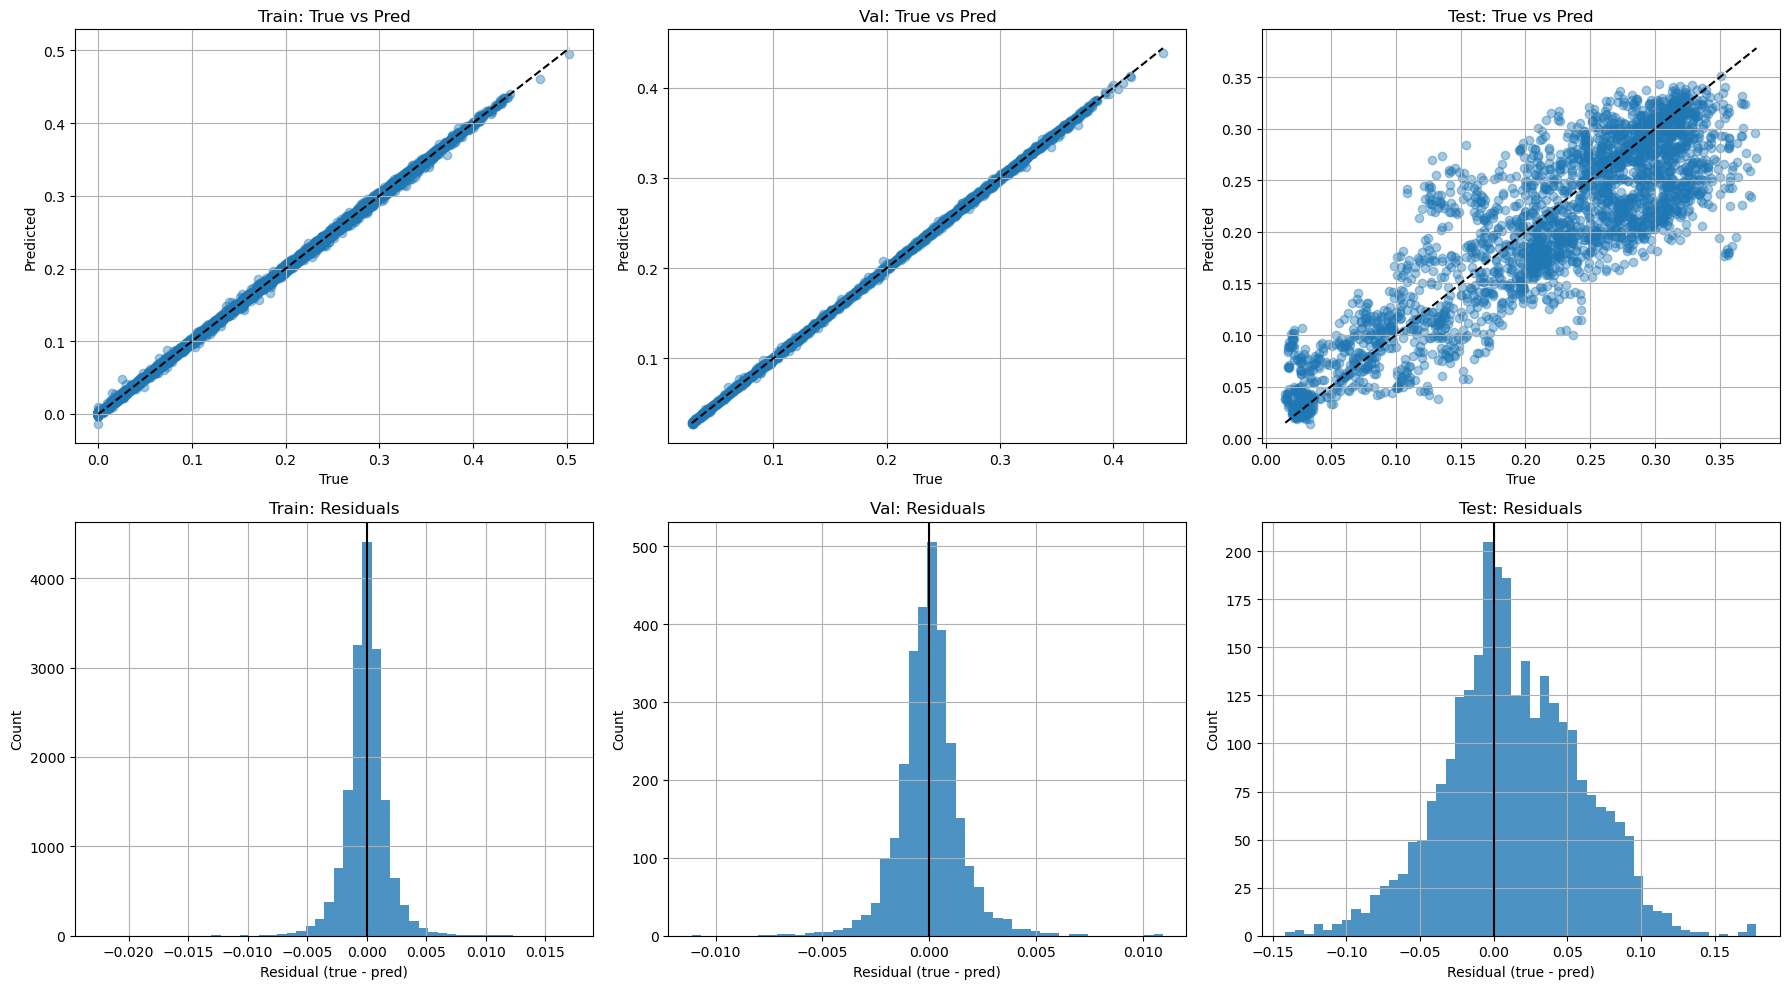

In [69]:
def scatter_plot(ax, y_true, y_pred, title):
    ax.scatter(y_true, y_pred, alpha=0.4)
    ax.plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="black",
        linestyle="--",
    )
    ax.set_title(title)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.grid(True)


def residual_hist(ax, y_true, y_pred, title):
    resid = y_true.values - y_pred
    ax.hist(resid, bins=50, alpha=0.8)
    ax.axvline(0, color="black")
    ax.set_title(title)
    ax.set_xlabel("Residual (true - pred)")
    ax.set_ylabel("Count")
    ax.grid(True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

scatter_plot(axes[0, 0], y_train, yhat_train_cal, "Train: True vs Pred")
scatter_plot(axes[0, 1], y_val,   yhat_val_cal,   "Val: True vs Pred")
scatter_plot(axes[0, 2], y_test,  yhat_test_cal,  "Test: True vs Pred")

residual_hist(axes[1, 0], y_train, yhat_train_cal, "Train: Residuals")
residual_hist(axes[1, 1], y_val,   yhat_val_cal,   "Val: Residuals")
residual_hist(axes[1, 2], y_test,  yhat_test_cal,  "Test: Residuals")

plt.tight_layout()
plt.show()

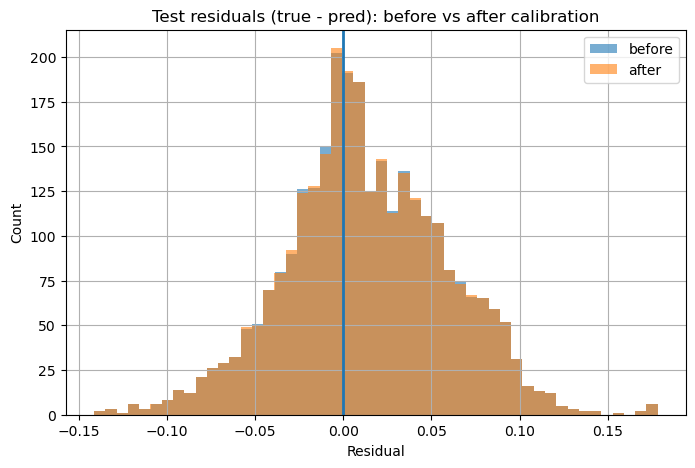

In [70]:
# res_before = y_test - yhat_test
res_before = y_test - yhat_test_tv
res_after  = y_test - yhat_test_cal

plt.figure()
plt.hist(res_before, bins=50, alpha=0.6, label="before")
plt.hist(res_after,  bins=50, alpha=0.6, label="after")
plt.axvline(0, linewidth=2)
plt.title("Test residuals (true - pred): before vs after calibration")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.legend()
plt.show()

### 7.4 Feature Importance

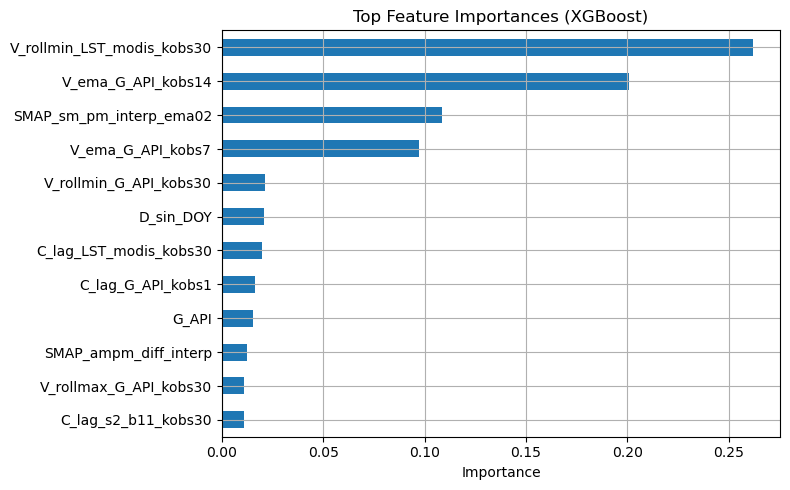

V_rollmin_LST_modis_kobs30    0.262242
V_ema_G_API_kobs14            0.200771
SMAP_sm_pm_interp_ema02       0.108526
V_ema_G_API_kobs7             0.097339
V_rollmin_G_API_kobs30        0.021399
                                ...   
A_d_LST_modis_kobs1           0.000085
A_d_SMAP_sm_interp_kobs1      0.000049
SMAP_sm_interp_mask           0.000000
G_DSLR_isnan                  0.000000
SMAP_sm_am_interp_mask        0.000000
Length: 108, dtype: float32

In [72]:
# importances = pd.Series(model_xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
importances = pd.Series(model_xgb_trainval.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.head(12).sort_values().plot(kind="barh")
plt.title("Top Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

## 8. Evaluation

### 8.1 Test Metrics

In [73]:
test_metrics = {
    "MAE":  mean_absolute_error(y_test, yhat_test_cal),
    "RMSE": rmse(y_test, yhat_test_cal),
    "R2":   r2_score(y_test, yhat_test_cal),
    "n":    len(y_test),
}

pd.DataFrame([test_metrics])

,MAE,RMSE,R2,n
0,0.03715,0.047756,0.739289,2829


### 8.2 Test Prediction Scatter

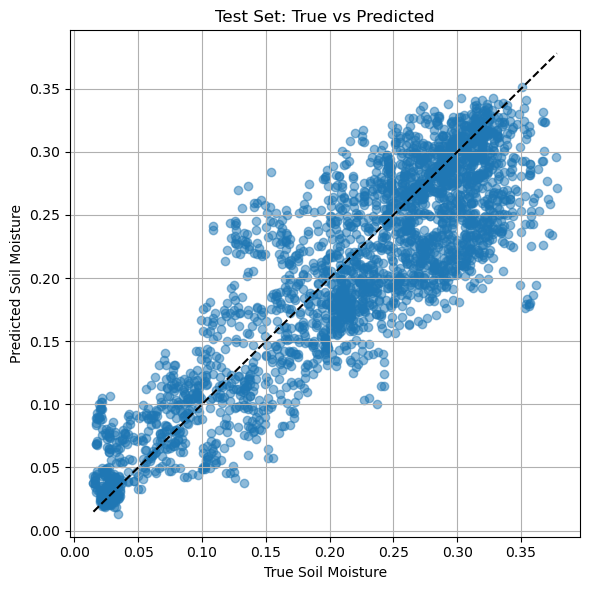

In [74]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, yhat_test_cal, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="black", linestyle="--")
plt.xlabel("True Soil Moisture")
plt.ylabel("Predicted Soil Moisture")
plt.title("Test Set: True vs Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

### 8.3 Bias

In [75]:
print(
    f"""
Residual diagnostics
--------------------
VAL  residual mean : {float((y_val.values - yhat_val_cal).mean()): .6f}
TEST residual mean : {float((y_test.values - yhat_test_cal).mean()): .6f}

Prediction ranges
-----------------
VAL  range : {float(yhat_val_cal.min()): .6f} to {float(yhat_val_cal.max()): .6f}
TEST range : {float(yhat_test_cal.min()): .6f} to {float(yhat_test_cal.max()): .6f}
"""
)


Residual diagnostics
--------------------
VAL  residual mean :  0.000000
TEST residual mean :  0.013007

Prediction ranges
-----------------
VAL  range :  0.026570 to  0.439037
TEST range :  0.013397 to  0.351117



## 9. Analysis

In [76]:
PRED = np.asarray(yhat_test_tv).ravel()
Y    = np.asarray(y_test).ravel()
DATE_COL = "date"

diag = test_df.copy()
diag[DATE_COL] = pd.to_datetime(diag[DATE_COL], errors="coerce")
diag["year"] = diag[DATE_COL].dt.year
diag["y"] = np.asarray(Y).ravel()
diag["pred"] = np.asarray(PRED).ravel()

In [77]:
overall_r2 = float(r2_score(diag["y"], diag["pred"]))

d2023 = diag[diag["year"] == 2023]
r2_2023 = float(r2_score(d2023["y"], d2023["pred"])) if len(d2023) >= 2 else np.nan

x = d2023["pred"].to_numpy(dtype=float)
y = d2023["y"].to_numpy(dtype=float)
m = np.isfinite(x) & np.isfinite(y)
x = x[m]; y = y[m]
if len(x) >= 2 and np.std(x) > 0:
    a, b = np.polyfit(x, y, 1)
    a, b = float(a), float(b)
else:
    a, b = np.nan, np.nan

                     metric     value                  target
            Overall Test R²  0.739264                    >0.8
                    2023 R² -0.474164                    >= 0
2023 slope (y ≈ a·pred + b)  0.540525 ~= 1.0 (no compression)


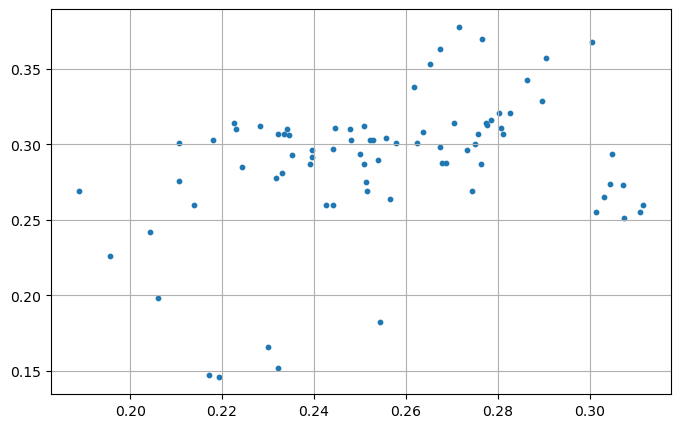

In [78]:
dash = pd.DataFrame({
    "metric": ["Overall Test R²", "2023 R²", "2023 slope (y ≈ a·pred + b)"],
    "value": [overall_r2, r2_2023, a],
    "target": [">0.8", ">= 0", "~= 1.0 (no compression)"],
})
print(dash.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.scatter(d2023["pred"], d2023["y"], s=10)

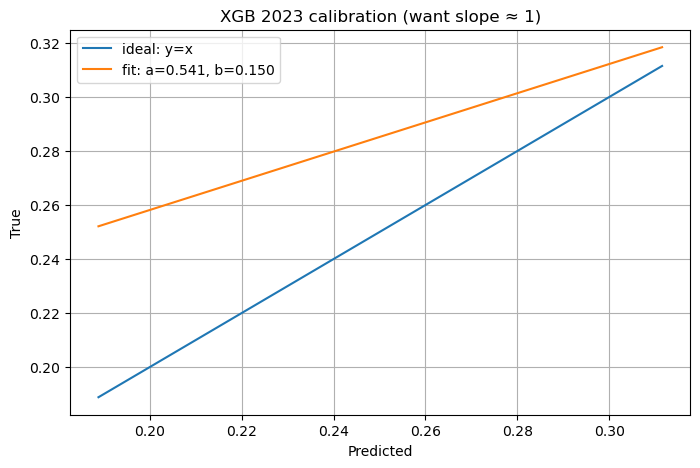

In [79]:
xmin = float(np.nanmin(d2023["pred"])) if len(d2023) else 0.0
xmax = float(np.nanmax(d2023["pred"])) if len(d2023) else 1.0
xs = np.linspace(xmin, xmax, 100) if xmax > xmin else np.linspace(0, 1, 100)
plt.plot(xs, xs, label="ideal: y=x")

if np.isfinite(a) and np.isfinite(b):
    plt.plot(xs, a * xs + b, label=f"fit: a={a:.3f}, b={b:.3f}")

plt.title("XGB 2023 calibration (want slope ≈ 1)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.grid(True)
plt.legend()
plt.show()

Rows:
  train: 16972
  test_2023: 79
Features kept (non-constant): 108

Mahalanobis Distance Summary (finite only)
Train mean distance: 7.889142531517581
2023 mean distance : 11.047770965531514
Train 95th percentile: 15.66861798216312
2023 95th percentile : 26.98453447059841


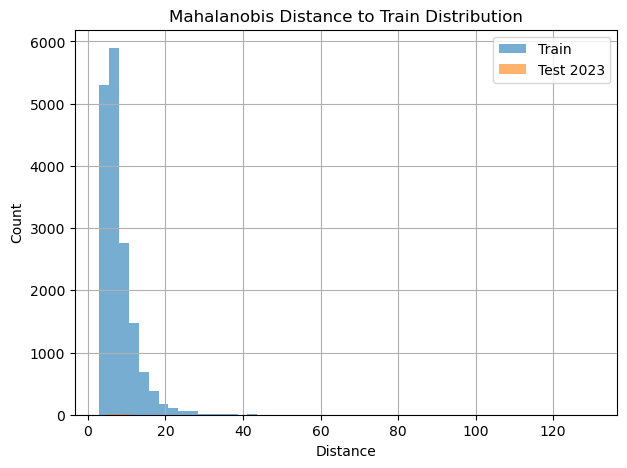

In [83]:
X_train_df = X_train.copy()
X_test_df  = X_test.copy()

X_train_df = X_train_df.replace([np.inf, -np.inf], np.nan)
X_test_df  = X_test_df.replace([np.inf, -np.inf], np.nan)

test_dates = pd.to_datetime(test_df["date"], errors="coerce")
mask_2023 = (test_dates.dt.year == 2023).values
X_test_2023_df = X_test_df.iloc[mask_2023].copy()

print("Rows:")
print("  train:", len(X_train_df))
print("  test_2023:", len(X_test_2023_df))

stds = X_train_df.std(axis=0, skipna=True)
keep_cols = stds[stds > 1e-12].index
X_train_df = X_train_df[keep_cols]
X_test_2023_df = X_test_2023_df[keep_cols]

print("Features kept (non-constant):", len(keep_cols))

med = X_train_df.median(axis=0, skipna=True)
X_train_imp = X_train_df.fillna(med)
X_test_2023_imp = X_test_2023_df.fillna(med)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp.values)
X_test_2023_scaled = scaler.transform(X_test_2023_imp.values)

cov = np.cov(X_train_scaled, rowvar=False)
cov_inv = inv(cov + 1e-3 * np.eye(cov.shape[0]))

mean_train = np.mean(X_train_scaled, axis=0)

maha_train = np.array([mahalanobis(x, mean_train, cov_inv) for x in X_train_scaled], dtype=float)
maha_2023  = np.array([mahalanobis(x, mean_train, cov_inv) for x in X_test_2023_scaled], dtype=float)

maha_train = maha_train[np.isfinite(maha_train)]
maha_2023  = maha_2023[np.isfinite(maha_2023)]

print("\nMahalanobis Distance Summary (finite only)")
print("Train mean distance:", float(np.mean(maha_train)))
print("2023 mean distance :", float(np.mean(maha_2023)))
print("Train 95th percentile:", float(np.percentile(maha_train, 95)))
print("2023 95th percentile :", float(np.percentile(maha_2023, 95)))

plt.figure(figsize=(7,5))
plt.hist(maha_train, bins=50, alpha=0.6, label="Train")
plt.hist(maha_2023, bins=50, alpha=0.6, label="Test 2023")
plt.title("Mahalanobis Distance to Train Distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.legend()
plt.show()

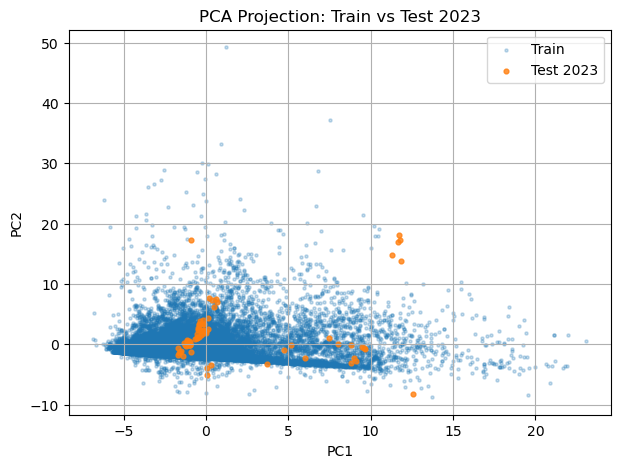

Explained variance ratio: [0.14722787 0.08405511]


In [85]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_2023_pca = pca.transform(X_test_2023_scaled)

plt.figure(figsize=(7,5))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], s=5, alpha=0.25, label="Train")
plt.scatter(X_test_2023_pca[:,0], X_test_2023_pca[:,1], s=12, alpha=0.8, label="Test 2023")
plt.title("PCA Projection: Train vs Test 2023")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

---

_Jakob Balkovec_